In [4]:
import pandas as pd
import numpy as np


In [5]:
df=pd.read_csv("df_procesado (1).csv")
df

,ID_Cliente,Edad,Salario_Estimado,Saldo_Bancario,Genero,Nivel_Educativo,Acepta_Tarjeta,Estado_Civil_Divorciado,Estado_Civil_Soltero
0,1001,38,4000.0,10122.466782,1.0,1.0,0,False,False
1,1002,26,2500.0,48205.653352,1.0,0.0,1,True,False
2,1003,36,4000.0,29014.856137,1.0,1.0,0,True,False
3,1005,32,5500.0,5336.546996,1.0,0.0,0,True,False
4,1006,50,4000.0,32775.948767,0.0,0.0,0,True,False
...,...,...,...,...,...,...,...,...,...
798,1994,66,8000.0,14482.384126,0.0,2.0,0,False,True
799,1996,46,2500.0,47751.229653,0.0,0.0,1,False,False
800,1998,48,2500.0,34237.893192,0.0,2.0,1,False,False
801,1999,59,5500.0,2357.276417,1.0,2.0,0,False,False


In [6]:
X=df.drop("Acepta_Tarjeta",axis=1)
X=X.iloc[:,1:]
X

,Edad,Salario_Estimado,Saldo_Bancario,Genero,Nivel_Educativo,Estado_Civil_Divorciado,Estado_Civil_Soltero
0,38,4000.0,10122.466782,1.0,1.0,False,False
1,26,2500.0,48205.653352,1.0,0.0,True,False
2,36,4000.0,29014.856137,1.0,1.0,True,False
3,32,5500.0,5336.546996,1.0,0.0,True,False
4,50,4000.0,32775.948767,0.0,0.0,True,False
...,...,...,...,...,...,...,...
798,66,8000.0,14482.384126,0.0,2.0,False,True
799,46,2500.0,47751.229653,0.0,0.0,False,False
800,48,2500.0,34237.893192,0.0,2.0,False,False
801,59,5500.0,2357.276417,1.0,2.0,False,False


In [7]:
y=df["Acepta_Tarjeta"]
y

,Acepta_Tarjeta
0,0
1,1
2,0
3,0
4,0
...,...
798,0
799,1
800,1
801,0


In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X)

StandardScaler()

In [9]:
#validacion cruzada
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2,random_state=42)

In [10]:
#Modelamiento
from sklearn.neighbors import KNeighborsClassifier


knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [11]:
knn.predict(X_test)

array([1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1])

In [12]:
compara=pd.DataFrame(y_test)
compara['prediccion']=knn.predict(X_test)
compara

,Acepta_Tarjeta,prediccion
192,1,1
294,0,0
168,1,0
521,1,0
535,1,0
...,...,...
362,1,1
355,1,0
436,1,0
770,0,1


In [13]:
# matriz de confusion
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,knn.predict(X_test))


array([[43, 34],
       [53, 31]])

In [14]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,knn.predict(X_test))

0.45962732919254656

In [15]:
knn1=KNeighborsClassifier(n_neighbors=7)
knn1.fit(X_train,y_train)
accuracy_score(y_test,knn1.predict(X_test))

0.5093167701863354

In [16]:
# clasification report
from sklearn.metrics import classification_report
print(classification_report(y_test,knn1.predict(X_test)))


              precision    recall  f1-score   support

           0       0.49      0.57      0.53        77
           1       0.54      0.45      0.49        84

    accuracy                           0.51       161
   macro avg       0.51      0.51      0.51       161
weighted avg       0.51      0.51      0.51       161



In [17]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,knn1.predict(X_test))

0.5119047619047619

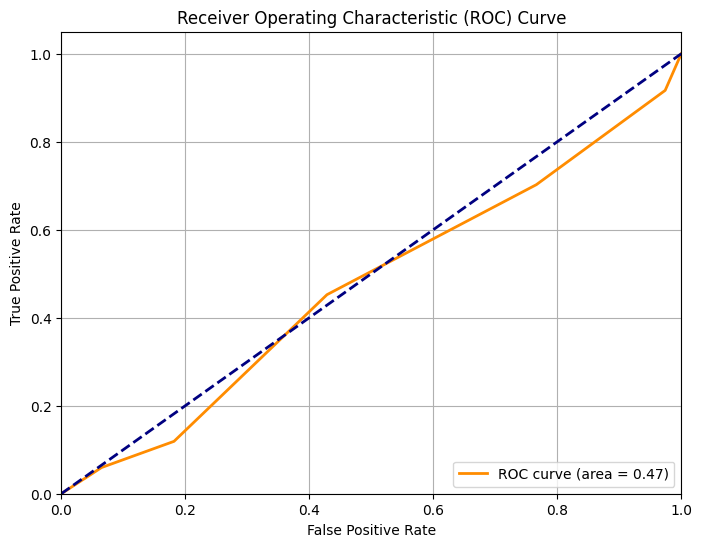

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_pred_proba = knn1.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()